In [2]:
import json
import os
import re
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Path to the directory containing OCR result files
ocr_results_dir = Path("/usr/project/xtmp/bsc32/gemini_ocr_output/clean")
# List to hold all OCR results
all_ocr_results = []
# Iterate over all JSONL files in the directory
for file_name in glob(str(ocr_results_dir / "*.jsonl")):
    file_path = Path(file_name)
    with open(file_path, 'r') as f:
        data = [json.loads(line) for line in f]
        all_ocr_results.extend(data)
# Now all_ocr_results contains the combined OCR results from all files
print(f"Total OCR results loaded: {len(all_ocr_results)}")
print("Sample OCR result:", all_ocr_results[0])



Total OCR results loaded: 53427
Sample OCR result: {'key': '3572139414/Fri_Nov_17_23:14:52_2023/18026681', 'text': '## Combined Text ##\nPlay-Doh\n#FLAG: MACHINE_READABLE_CODE,BRANDING_LOGOS', 'file_path': ['/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000007.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000009.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000011.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000018.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000019.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/000020.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Berkeley_Way_West/3572139414/Fri_Nov_17_23:14:52_2023/18026681/0

In [4]:
# convert to dataframe

categories = [
    "PII",
    "CONFIDENTIAL_INFO",
    "SECURITY_INFO",
    "MACHINE_READABLE_CODE",
    "BRANDING_LOGOS",
    "OTHER",
]
# split file_path into components
for result in all_ocr_results:
    path_parts = result["file_path"][0].split(os.sep)
    if path_parts[-6] == 'N':
        path_parts = result["file_path"][0].replace("N/A", "N_A").split("/")
    result["scene_id"] = path_parts[-4]
    result["building"] = path_parts[-5]
    result["lab"] = path_parts[-6]
    if "key" in result:
        del result["key"]

    # check for presence of #FLAG in text
    if result['text'] is None:
        result['text'] = ""
    result["is_flagged"] = "#FLAG" in result["text"]
    if result["is_flagged"]:
        result["flag_categories"] = result["text"].split("#FLAG")[1].replace("[", "").replace("]", "").replace(":", "").split(",")
    else:
        result["flag_categories"] = []
df = pd.DataFrame(all_ocr_results)
df.head()

,text,file_path,scene_id,building,lab,is_flagged,flag_categories
0,## Combined Text ##\nPlay-Doh\n#FLAG: MACHINE_...,[/usr/project/xtmp/bsc32/droid/AUTOLab/Berkele...,3572139414,Berkeley_Way_West,AUTOLab,True,"[ MACHINE_READABLE_CODE, BRANDING_LOGOS]"
1,## Combined Text ##\nCRAFTSMAN\nUSA\n42\n2.49\...,[/usr/project/xtmp/bsc32/droid/AUTOLab/Berkele...,3572139414,Berkeley_Way_West,AUTOLab,True,[BRANDING_LOGOS]
2,## Combined Text ##\nSODIUM\nSUGARS\nPROTEIN\n...,[/usr/project/xtmp/bsc32/droid/AUTOLab/Berkele...,3572139414,Berkeley_Way_West,AUTOLab,False,[]
3,## Combined Text ##\nNATUR\nServing\nPER\n(Bar...,[/usr/project/xtmp/bsc32/droid/AUTOLab/Berkele...,3572139414,Berkeley_Way_West,AUTOLab,True,[ MACHINE_READABLE_CODE]
4,## Combined Text ##\nDANGER OF SUFFOCATION. KE...,[/usr/project/xtmp/bsc32/droid/AUTOLab/Berkele...,3572139414,Berkeley_Way_West,AUTOLab,True,[BRANDING_LOGOS]


In [5]:
# helper function to get number of input images per lab
def get_num_input_images_per_lab(lab_name):
    name_pattern = re.compile(r"'name': '([^']+)'")
    file_path = f"/usr/project/xtmp/bsc32/droid_yoloe/{lab_name}/predictions.txt"
    image_num = 0
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            names = re.findall(name_pattern, line)
            if names and names != ["person"]:
                image_num += 1
    return image_num

Number of input images per lab: {'AUTOLab': 15452, 'TRI': 30130, 'RAD': 2098, 'GuptaLab': 4923, 'ILIAD': 5257, 'PennPAL': 3795, 'IPRL': 4690, 'CLVR': 6099, 'IRIS': 9544, 'REAL': 12994, 'RAIL': 11989, 'RPL': 2727, 'WEIRD': 2303}


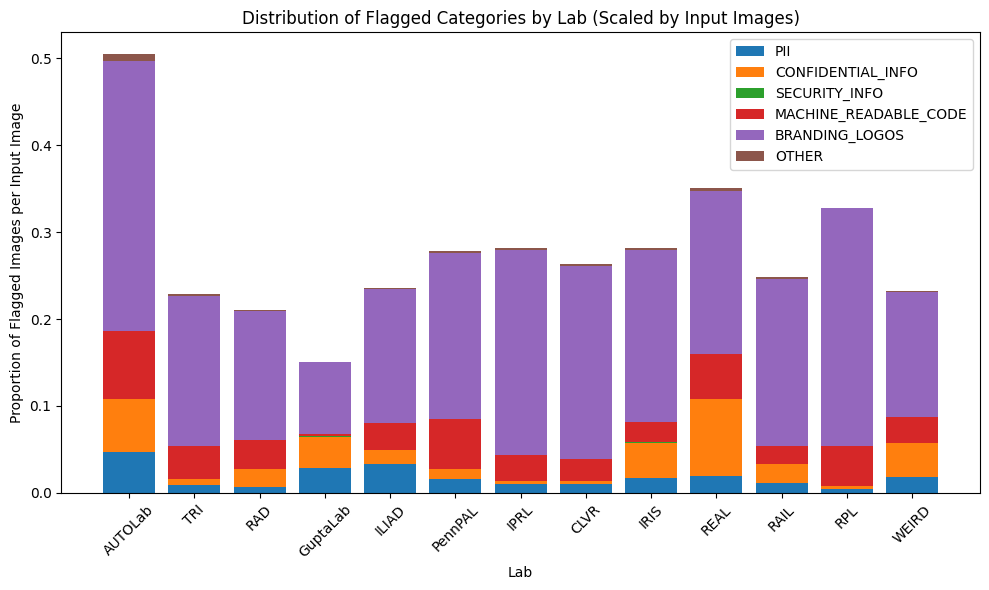

In [6]:
# plot distribution of categories in flagged results as a stacked bar chart of labs
# scale by number of input images per lab
images_per_lab = {}
for lab in df["lab"].unique():
    images_per_lab[lab] = get_num_input_images_per_lab(lab)
print("Number of input images per lab:", images_per_lab)
flagged_df = df[df["is_flagged"]]
categories_by_lab = {}
for lab in flagged_df["lab"].unique():
    lab_df = flagged_df[flagged_df["lab"] == lab]
    category_counts = {category: 0 for category in categories}
    for categories_list in lab_df["flag_categories"]:
        for category in categories_list:
            category = category.strip()
            if category in category_counts:
                category_counts[category] += 1
    categories_by_lab[lab] = category_counts

# Scale the counts by the number of input images per lab
for lab in categories_by_lab:
    num_images = images_per_lab[lab]
    for cat in categories_by_lab[lab]:
        categories_by_lab[lab][cat] /= num_images

labs = list(categories_by_lab.keys())
category_counts_matrix = np.array([list(categories_by_lab[lab].values()) for lab in labs])
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(labs))
for i, category in enumerate(categories):
    counts = category_counts_matrix[:, i]
    ax.bar(labs, counts, bottom=bottom, label=category)
    bottom += counts
ax.set_xlabel("Lab")
ax.set_ylabel("Proportion of Flagged Images per Input Image")
ax.set_title("Distribution of Flagged Categories by Lab (Scaled by Input Images)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

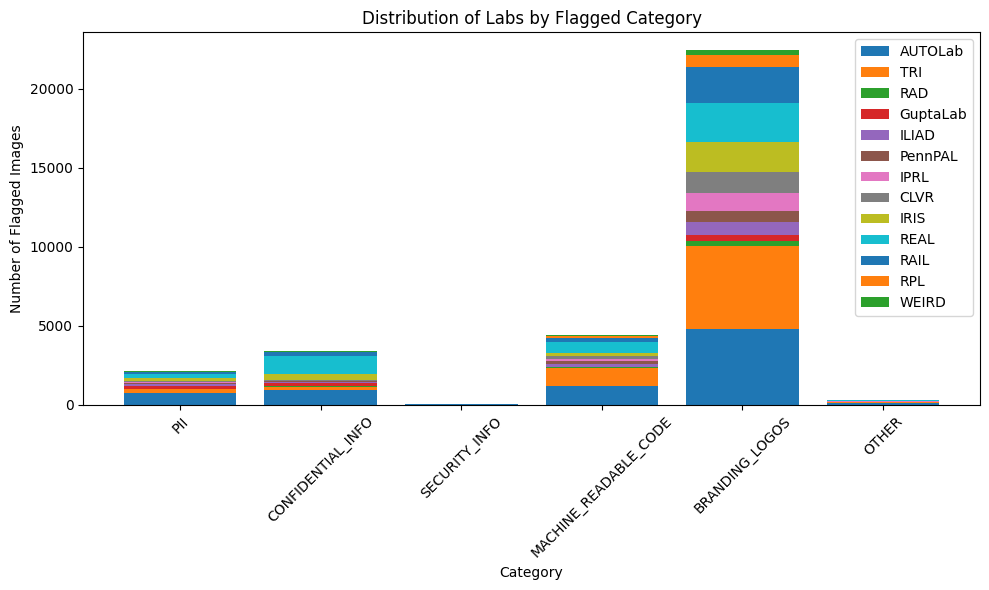

In [7]:
# plot distribution the other way (categories by lab) as a stacked bar chart
categories_by_category = {}
for category in categories:
    category_df = flagged_df[flagged_df["flag_categories"].apply(lambda x: category in [c.strip() for c in x])]
    lab_counts = {lab: 0 for lab in flagged_df["lab"].unique()}
    for lab in category_df["lab"]:
        lab_counts[lab] += 1
    categories_by_category[category] = lab_counts
categories_list = list(categories_by_category.keys())
lab_counts_matrix = np.array([list(categories_by_category[category].values()) for category in categories_list])
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(categories_list))
for i, lab in enumerate(flagged_df["lab"].unique()):
    counts = lab_counts_matrix[:, i]
    ax.bar(categories_list, counts, bottom=bottom, label=lab)
    bottom += counts
ax.set_xlabel("Category")
ax.set_ylabel("Number of Flagged Images")
ax.set_title("Distribution of Labs by Flagged Category")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

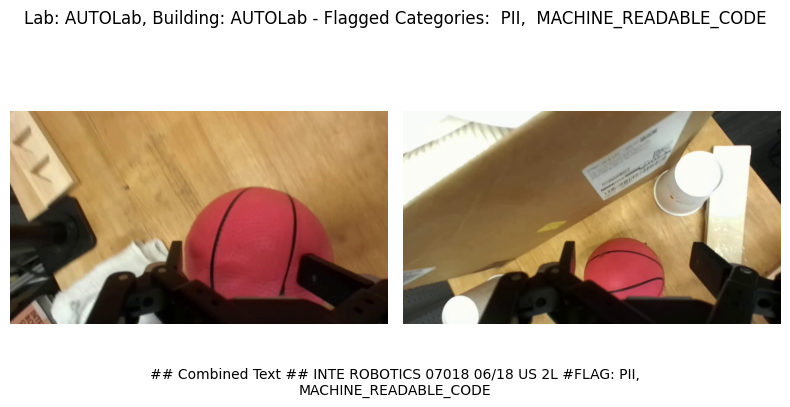

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/AUTOLab/3774560981/Tue_Nov_21_10:59:57_2023/18026681/000014.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/AUTOLab/3774560981/Tue_Nov_21_10:59:57_2023/18026681/000021.png']


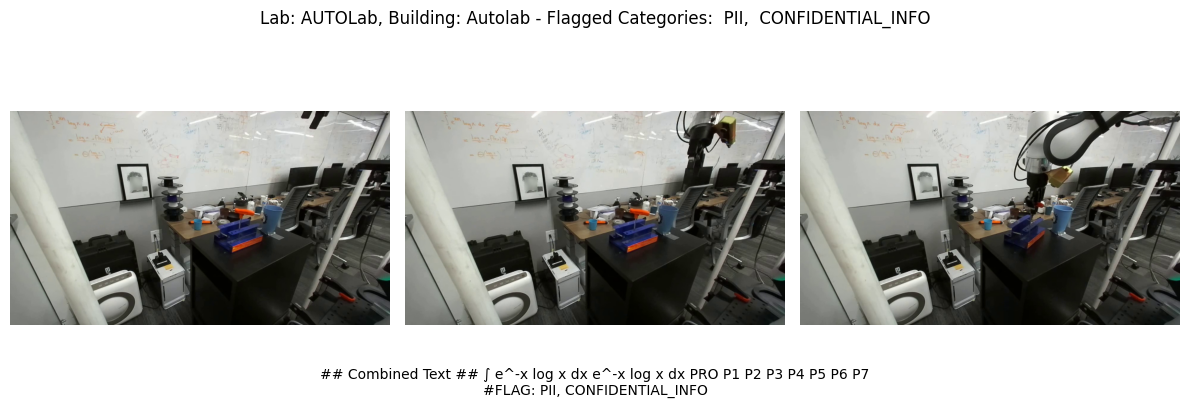

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:02:16_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:02:16_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:02:16_2023/22008760/000003.png']


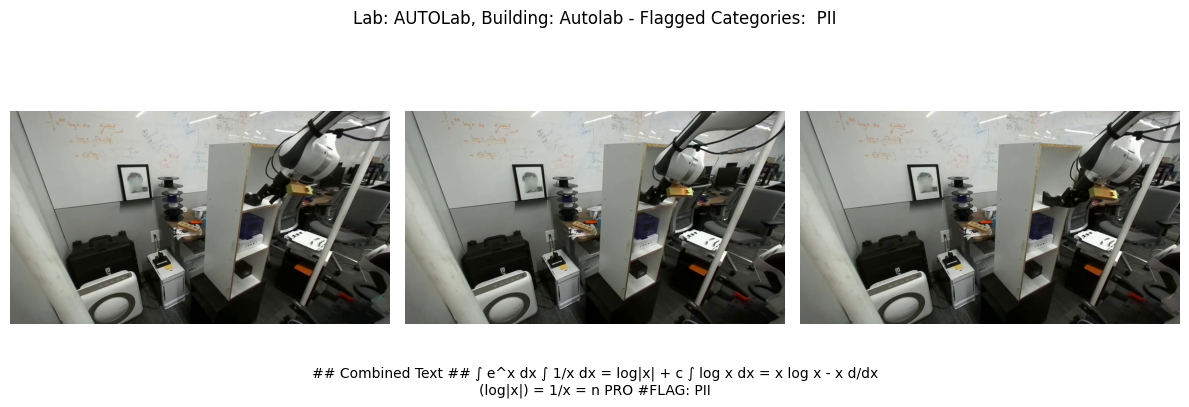

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:41:29_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:41:29_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:41:29_2023/22008760/000003.png']


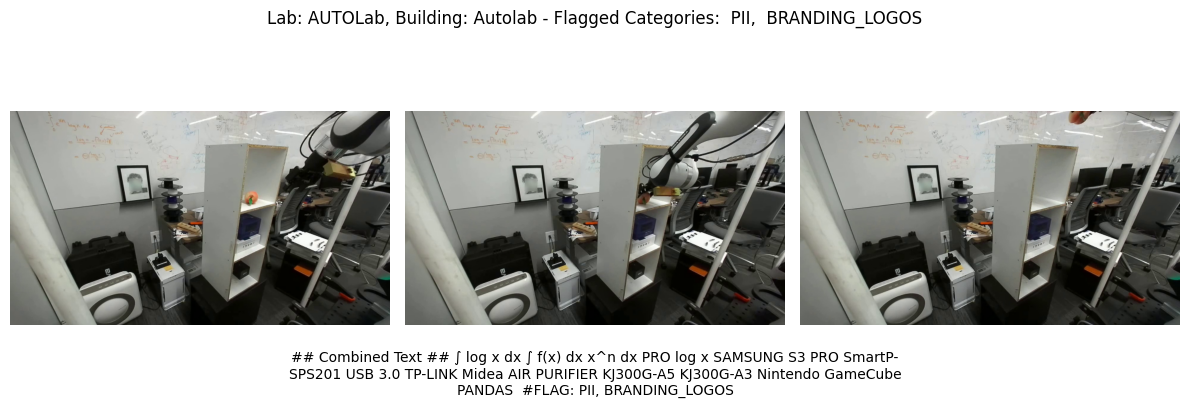

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:36:22_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:36:22_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:36:22_2023/22008760/000003.png']


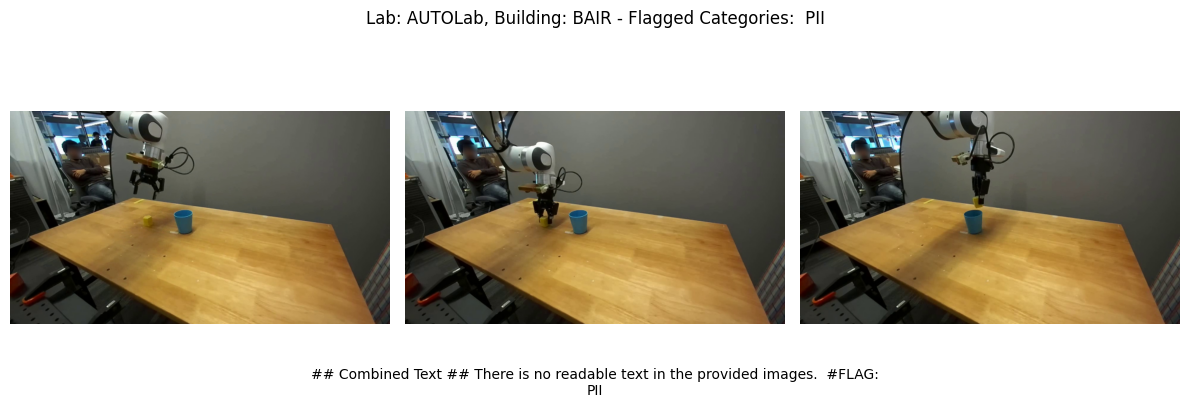

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/BAIR/65137982/Thu_Aug_17_17:46:22_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/BAIR/65137982/Thu_Aug_17_17:46:22_2023/24400334/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/BAIR/65137982/Thu_Aug_17_17:46:22_2023/24400334/000003.png']


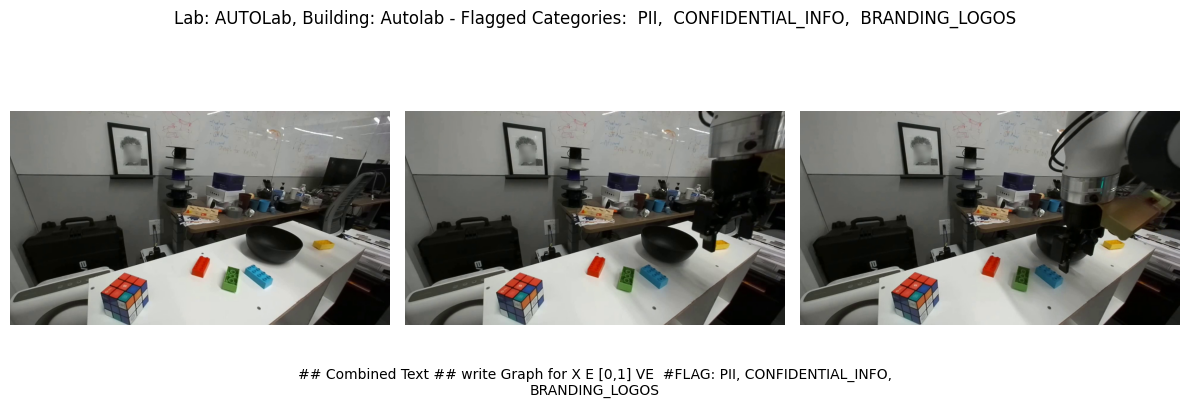

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_21:44:18_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_21:44:18_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_21:44:18_2023/22008760/000003.png']


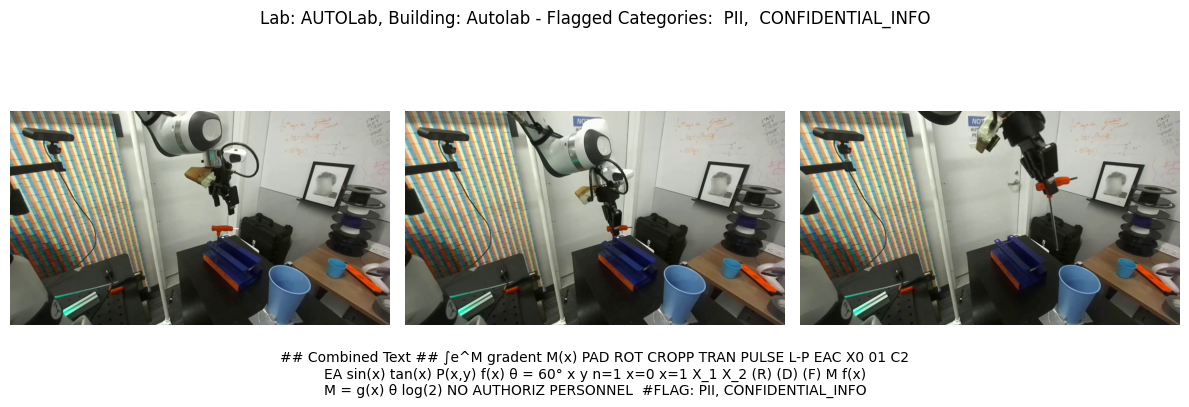

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:32:35_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:32:35_2023/24400334/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:32:35_2023/24400334/000003.png']


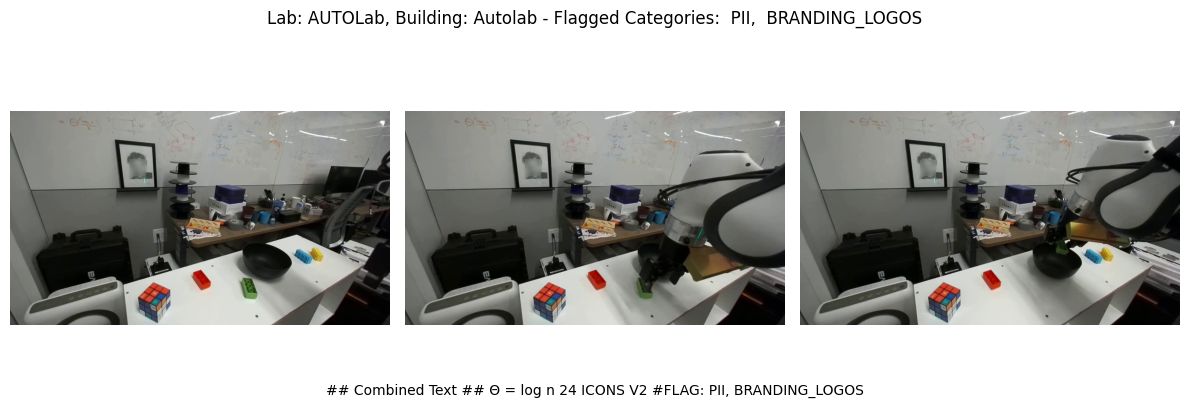

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_22:03:04_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_22:03:04_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_22:03:04_2023/22008760/000003.png']


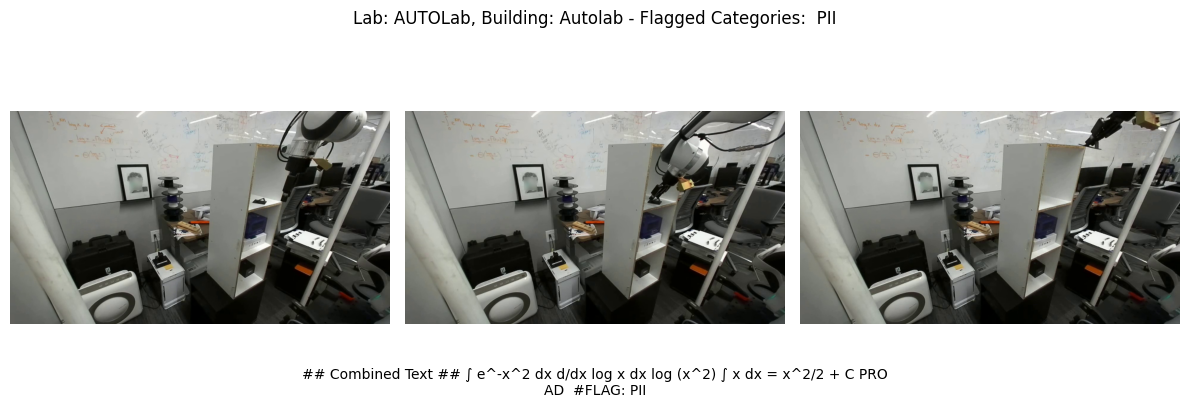

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_21:16:45_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_21:16:45_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_21:16:45_2023/22008760/000003.png']


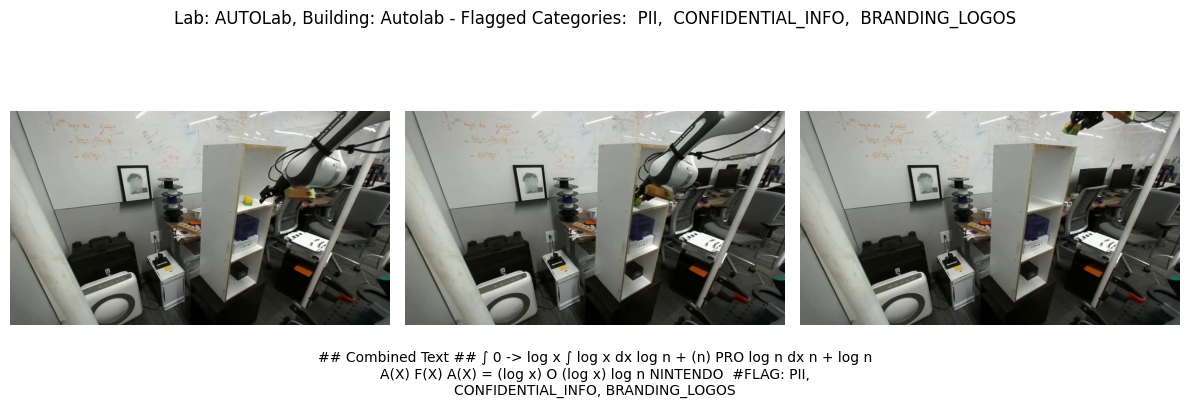

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:27:32_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:27:32_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:27:32_2023/22008760/000003.png']


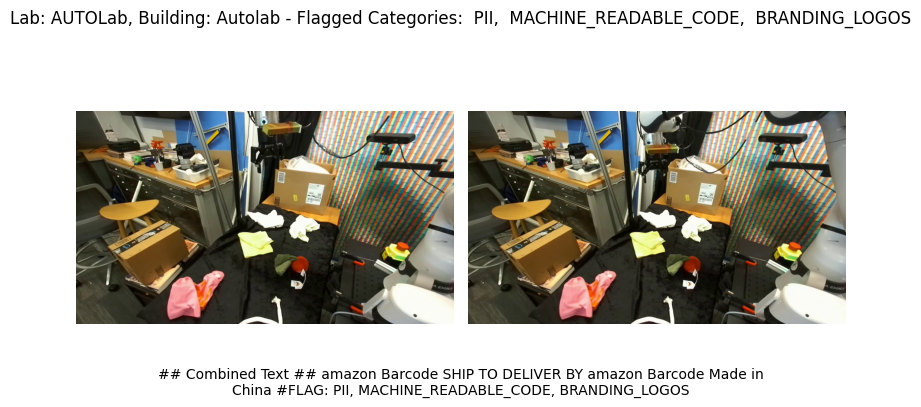

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/2168420340/Sat_Nov_25_10:39:57_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/2168420340/Sat_Nov_25_10:39:57_2023/22008760/000003.png']


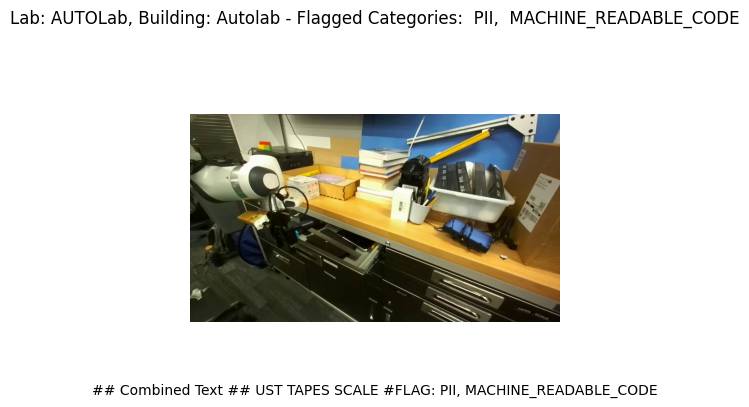

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/8756300955/Sat_Oct_21_19:07:48_2023/24400334/000003.png']


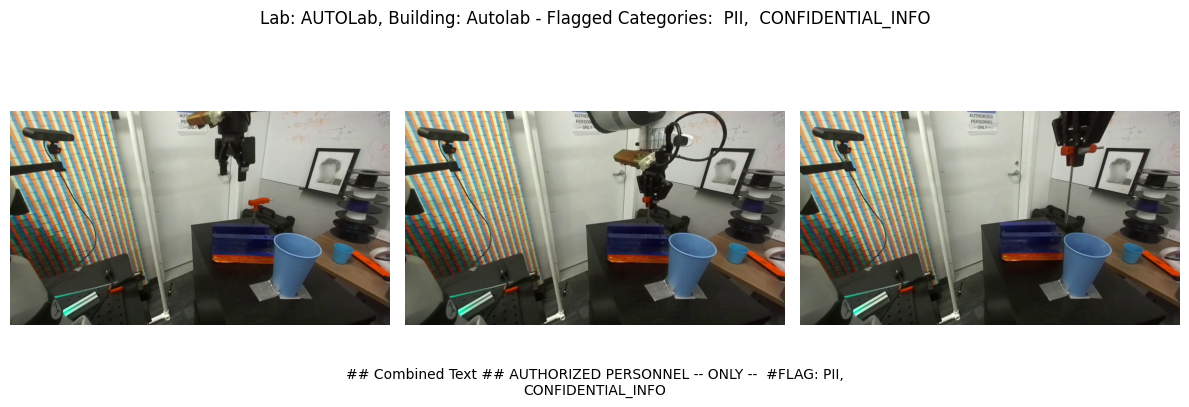

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:12:27_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:12:27_2023/24400334/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:12:27_2023/24400334/000003.png']


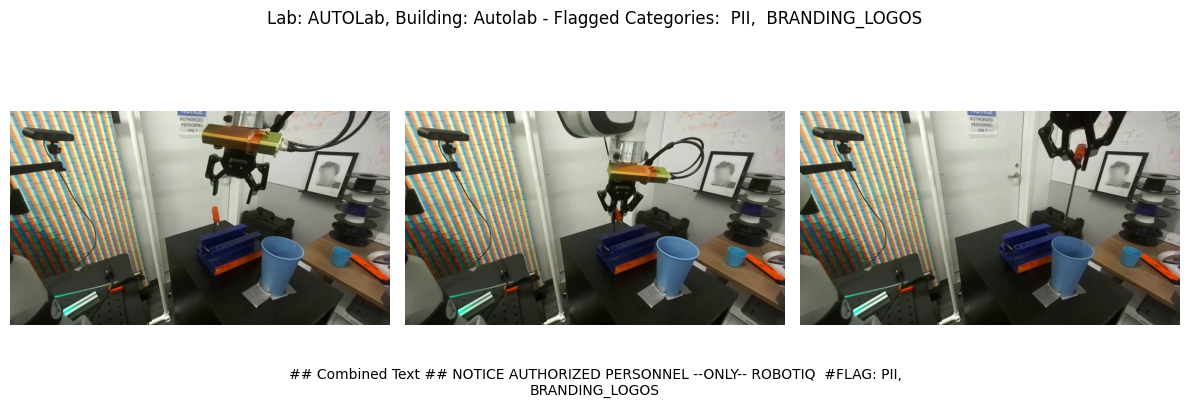

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/8639330896/Fri_Oct_13_18:56:35_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/8639330896/Fri_Oct_13_18:56:35_2023/24400334/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/8639330896/Fri_Oct_13_18:56:35_2023/24400334/000003.png']


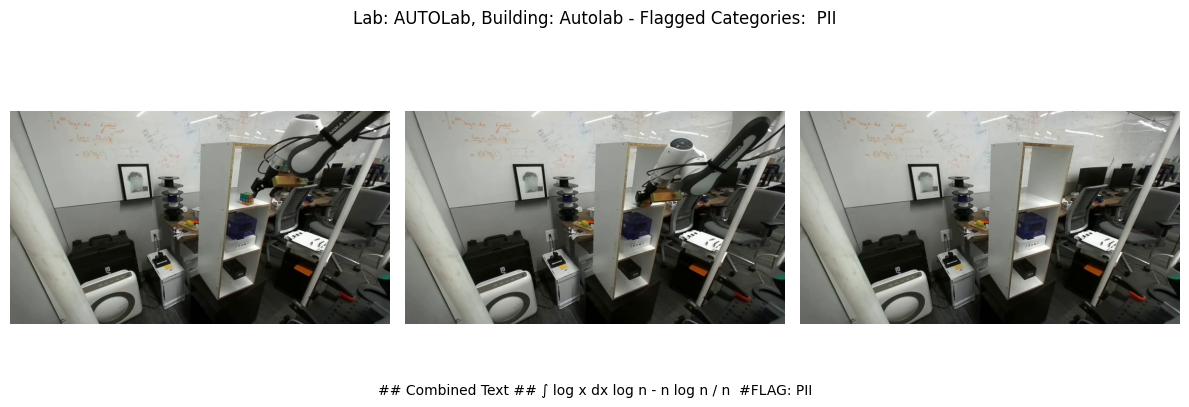

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:20:35_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:20:35_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:20:35_2023/22008760/000003.png']


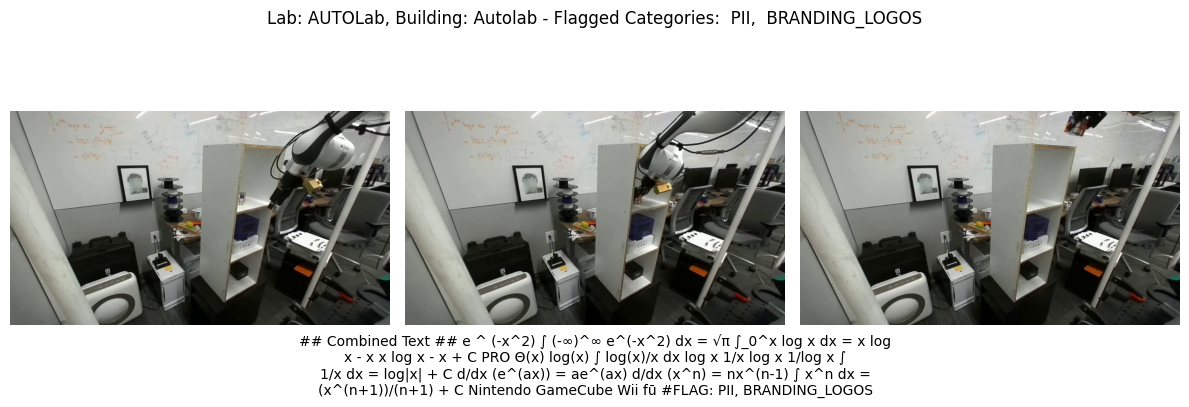

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:24:51_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:24:51_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:24:51_2023/22008760/000003.png']


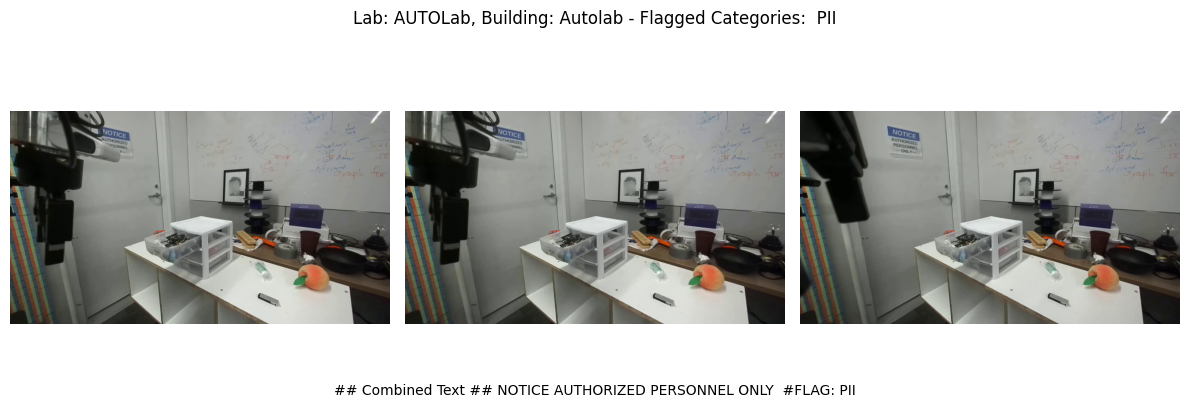

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_20:07:40_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_20:07:40_2023/24400334/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Sat_Oct_14_20:07:40_2023/24400334/000003.png']


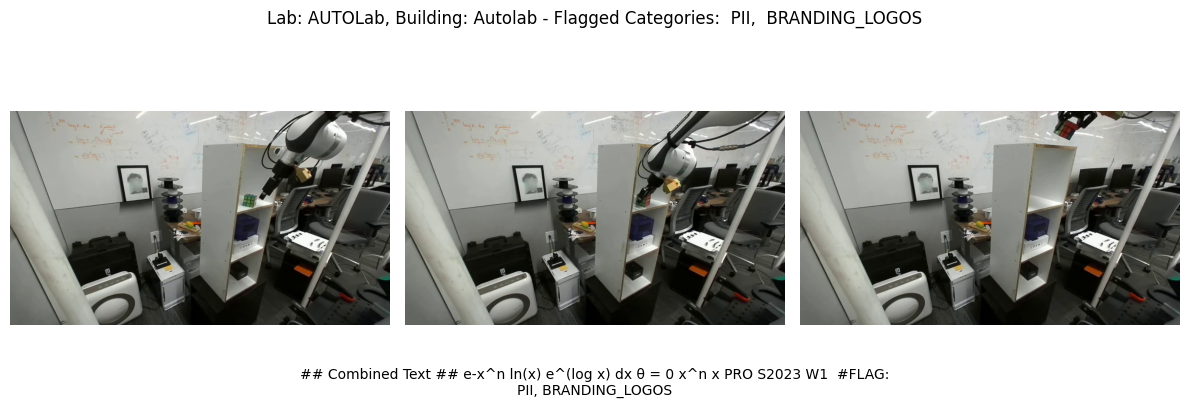

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:26:19_2023/22008760/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:26:19_2023/22008760/000002.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_20:26:19_2023/22008760/000003.png']


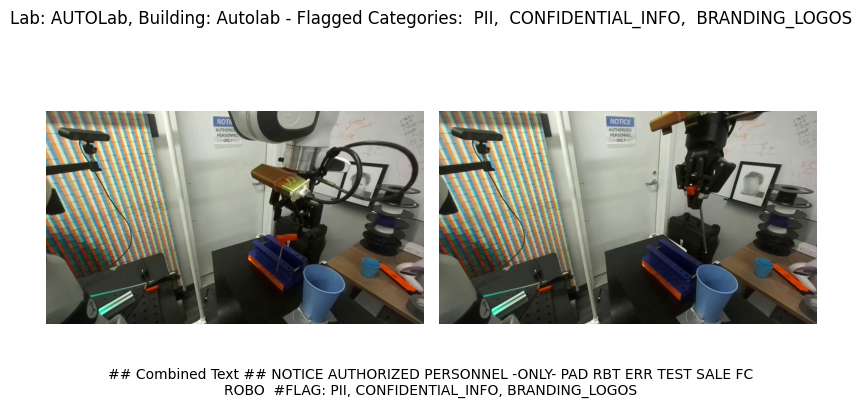

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:28:42_2023/24400334/000001.png', '/usr/project/xtmp/bsc32/droid/AUTOLab/Autolab/3163748394/Fri_Oct_13_19:28:42_2023/24400334/000003.png']


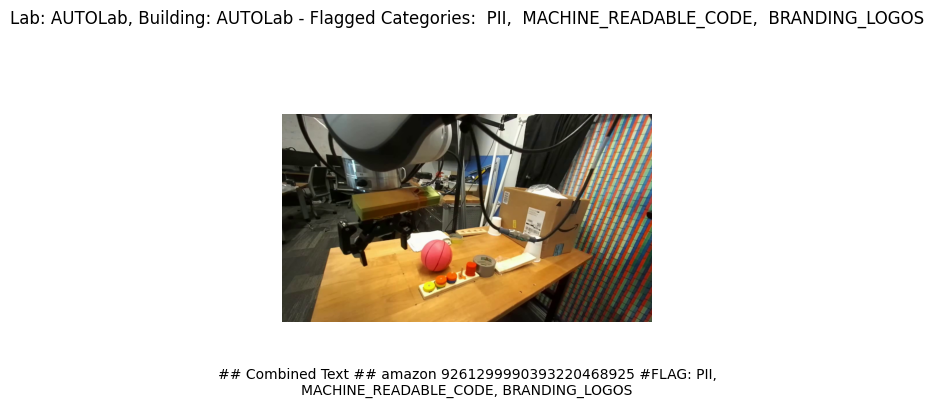

Image paths: ['/usr/project/xtmp/bsc32/droid/AUTOLab/AUTOLab/3774560981/Tue_Nov_21_10:25:49_2023/22008760/000001.png']


In [10]:
import textwrap

# Visualize results for a specific category
category_to_visualize = "PII"
category_df = flagged_df[flagged_df["flag_categories"].apply(lambda x: category_to_visualize in [c.strip() for c in x])]
# Filter for specific lab and building
category_df = category_df[(category_df['lab'] == 'AUTOLab')]
sample_size = min(20, len(category_df))
sample_df = category_df.sample(n=sample_size, random_state=42)
for _, row in sample_df.iterrows():
    img_paths = row["file_path"]  # list of image paths
    num_images = len(img_paths)
    if num_images == 0:
        continue
    # Determine grid size, e.g., up to 5 columns
    cols = min(5, num_images)
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, img_path in enumerate(img_paths):
        img = plt.imread(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
    # Hide unused axes
    for i in range(num_images, rows * cols):
        axes[i].axis('off')
    # Add title
    fig.suptitle(f"Lab: {row['lab']}, Building: {row['building']} - Flagged Categories: {', '.join(row['flag_categories'])}")
    # Add text at bottom
    wrapped_text = "\n".join(textwrap.wrap(row["text"], width=80))
    plt.figtext(0.5, 0.01, wrapped_text, ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"Image paths: {img_paths}")
